# ¡Hola José! ¿Cómo estás? 🙂
<div class="alert alert-block alert-info">
   
Mi nombre es <b>Andrés Barbosa</b> 👋 

Un gusto conocerte, seré tu revisor en este proyecto.
A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:
Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y
corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para
mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.
Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más
precisa, junto con algunos ejemplos prácticos. También estoy abierto a responder cualquier duda que
tengas.
Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.
Puedes encontrar mis comentarios en cuadros verdes, amarillos o rojos como este:
</div>
<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>
Éxito. Todo se ha hecho de forma correcta.
</div>
<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>
Observación. Algunas recomendaciones o mejoras menores.
</div>
<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>
Necesita arreglos. Este apartado requiere algunas correcciones. El trabajo no puede ser aceptado
con comentarios rojos.
</div>
<div class="alert alert-block alert-info">
Puedes responder utilizando este formato:
Respuesta del estudiante.
</div>

Empecemos! 🚀

<div class="alert alert-block alert-danger">
<b>Comentario general del revisor</b><br><br>
¡Hola José! Se ve un buen trabajo en toda la parte de preparación y exploración: la carga y concatenación de las cuatro tablas por <code>customerID</code>, el tratamiento de los nulos estructurales, la revisión del desbalance de clases y la matriz de correlación para detectar multicolinealidad. Esa base está muy bien.<br><br>
Sin embargo, encontré dos problemas de fondo que afectan la validez del modelo, así que todavía no puedo aprobarlo y te pido una reentrega:<br><br>
<b>1. La variable objetivo <code>churn</code> quedó invertida.</b> Te lo señalo en la celda donde la definís.<br>
<b>2. Hay una fuga de información en la antigüedad (<code>Tenure_Months</code>).</b> Es la causa de que las métricas den casi perfectas (ROC-AUC de 0.9999), que no es un resultado realista.<br><br>
Además, el notebook termina sin una conclusión ni un reporte final (la última celda tiene texto de la plantilla), que es una parte esperada del proyecto. Te dejo el detalle en los comentarios rojos, algunas observaciones en amarillo y comentarios verdes en lo que está bien. ¡Quedo atento a tu reentrega!
</div>

<div class="alert alert-block alert-success">
<b>Comentario general del revisor (segunda iteración)</b><br><br>
¡Hola de nuevo, José! Revisé tu reentrega y corregiste los puntos que te había señalado, así que el proyecto queda <b>aprobado</b>. Invertiste bien la variable objetivo (ahora el 1 es el cliente que cancela), eliminaste la fuga en <code>Tenure_Months</code> midiendo la antigüedad hasta una fecha de corte fija para todos, y las métricas ahora son realistas (ROC-AUC de 0.85 en la prueba, en lugar del 0.9999 anterior). También separaste un conjunto de validación para elegir el modelo y el umbral (dejando la prueba solo para la evaluación final), corregiste el <code>fit_transform</code> y el <code>drop</code> de <code>TotalCharges</code>, y agregaste el informe final con la recomendación de negocio.<br><br>
Te dejo un par de observaciones menores para terminar de pulir. ¡Felicitaciones por el trabajo de corrección!
</div>

# Tasa de cancelamiento de servicio Telecom

Al operador de telecomunicaciones Interconnect le gustaría poder pronosticar su tasa de cancelación de clientes. Si se descubre que un usuario o usuaria planea irse, se le ofrecerán códigos promocionales y opciones de planes especiales. El equipo de marketing de Interconnect ha recopilado algunos de los datos personales de sus clientes, incluyendo información sobre sus planes y contratos.

Analicemos entonces los datos para crear un reporte de los usuarios calificados como proximos a dejar el servicio.

## Analisis Exploratorio de los datos

### Preparacion de los datos

Comenzamos importando las librerias necesarias para el analisis de los datos.

In [64]:
#importaciones de los datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

print('Importacion correcta de librerias')

Importacion correcta de librerias


Al importar los datos por separado tendremos que crear un solo dataframe con el concatenado de los datos, despues de eso vamos a corregir los tipos de datos y realizar una limpieza del data frame. 


In [65]:
# importamos los datos en un data frame por separado
ruta = '/datasets/final_provider/'
#ruta = 'final_provider/final_provider/'

contract_df = pd.read_csv(ruta + 'contract.csv')
personal_df = pd.read_csv(ruta + 'personal.csv')
internet_df = pd.read_csv(ruta + 'internet.csv')
phone_df = pd.read_csv(ruta + 'phone.csv')

In [66]:
# Creamos un cocatenado de los data frames por el campo customerID, que es el campo en común entre todos los data frames
concatenado_list = [contract_df, personal_df, internet_df, phone_df]
concat_index = [df.set_index('customerID') for df in concatenado_list]
concatenado = pd.concat(concat_index, axis=1)

In [67]:
# Obtengamos informacion del data frame para identificar y corregir informacion
print("-" * 30)
print('Informacion general de los datos')
print("-" * 30)
print(concatenado.info())


------------------------------
Informacion general de los datos
------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   BeginDate         7043 non-null   object 
 1   EndDate           7043 non-null   object 
 2   Type              7043 non-null   object 
 3   PaperlessBilling  7043 non-null   object 
 4   PaymentMethod     7043 non-null   object 
 5   MonthlyCharges    7043 non-null   float64
 6   TotalCharges      7043 non-null   object 
 7   gender            7043 non-null   object 
 8   SeniorCitizen     7043 non-null   int64  
 9   Partner           7043 non-null   object 
 10  Dependents        7043 non-null   object 
 11  InternetService   5517 non-null   object 
 12  OnlineSecurity    5517 non-null   object 
 13  OnlineBackup      5517 non-null   object 
 14  DeviceProtection  5517 non-null

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b><br><br>
Muy bien la carga y unificación de los datos. Importás las cuatro tablas por separado y las combinás en un solo dataframe usando <code>customerID</code> como índice común, que es la forma correcta de armar el dataset maestro para este proyecto.
</div>

### Analisis de valores faltantes e ingenieria de caracteristicas 

In [68]:
# Quitamos los duplicados del data frame concatenado
concatenado.drop_duplicates(inplace=True)

#cambiamos los datos que contengan espacios en blanco a NAN y cambiamos el formato de las columas con tipo de datos incorrecto
concatenado['TotalCharges'] = concatenado['TotalCharges'].replace(' ', np.nan).astype(float)
concatenado['MonthlyCharges'] = concatenado['MonthlyCharges'].astype(float)
concatenado['BeginDate'] = pd.to_datetime(concatenado['BeginDate'])

# Dfinimos la variable objetivo, que es la colmna EndDate, si el valor es no, quiere decir que el contrato sigue activo y estara representado por el valor 1
# 1 si el contrato sigue activo ('No'), 0 si ya terminó
concatenado['churn'] = np.where(concatenado['EndDate'] != 'No', 1, 0)

concatenado['EndDate'] = concatenado['EndDate'].replace('No', np.nan)
concatenado['EndDate'] = pd.to_datetime(concatenado['EndDate'])


#Agregamos una fecha de corte para el calculo de la antiguedad de los clientes, ya que no todos los clientes tienen fecha de baja
fecha_corte = pd.to_datetime('2021-01-01')

concatenado['EndDate'] = concatenado['EndDate'].fillna(fecha_corte)

# Calculamos la antiguedad de los clientes en meses, tomando en cuenta que algunos clientes no tienen fecha de baja, por lo que se toma la fecha de corte como fecha de baja
# Dividir entre 30.44: Es el estándar estadístico para convertir días a meses de forma precisa, considerando años bisiestos y meses de 28, 30 y 31 días.
concatenado['Tenure_Months'] = ((fecha_corte - concatenado['BeginDate']).dt.days / 30.44).astype(int)

# borramos las columnas que ya no son necesarias para el analisis, como BeginDate y EndDate
concatenado = concatenado.drop(columns=['BeginDate', 'EndDate', ])

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b><br><br>
Acá hay dos puntos de fondo para corregir.<br><br>
<b>1. La variable objetivo está invertida.</b> Definís <code>churn = np.where(EndDate == 'No', 1, 0)</code>, es decir, le asignás 1 a los clientes que <b>siguen activos</b> y 0 a los que <b>cancelaron</b>. El objetivo del proyecto es predecir a quienes se van, así que la clase positiva (1) debería ser el cliente que canceló (<code>EndDate</code> distinto de 'No') y 0 el que sigue activo. Tal como está, el modelo aprende a predecir lo contrario de lo que se pide, y además el positivo termina siendo la clase mayoritaria, lo que infla el F1.<br><br>
<b>2. Fuga de información en <code>Tenure_Months</code>.</b> Calculás la antigüedad como <code>(EndDate - BeginDate)</code>, y para los clientes que cancelaron <code>EndDate</code> es su fecha real de baja, que es justamente lo que define el objetivo. Eso convierte la antigüedad en una variable derivada de la respuesta: a quien se fue le medís el tiempo hasta el día en que se fue, y a quien sigue activo hasta la fecha de corte. Para evitar la fuga, la antigüedad de <b>todos</b> los clientes debería medirse hasta una misma fecha de corte fija, sin usar la fecha de baja real de los que cancelaron.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (segunda iteración)</b><br><br>
Corregido. La variable objetivo ahora asigna 1 al cliente que cancela (<code>EndDate != 'No'</code>) y 0 al que sigue activo, que es lo correcto. Y la antigüedad se calcula como <code>(fecha_corte - BeginDate)</code> para todos los clientes por igual, sin usar la fecha de baja real, así que la fuga quedó resuelta. Ambos puntos de fondo están bien solucionados.<br><br>
Un detalle menor para pulir: el comentario que quedó encima de la definición de <code>churn</code> todavía describe la lógica anterior ("1 si el contrato sigue activo"), conviene actualizarlo para que no contradiga al código, que ya es el correcto.
</div>

Agregando la columna de tenure es mas facil identificar el la influencia de la antiguedad en la decision de cancelacion del servicio

Colocamos los tipos correctos de datos para identificar nuestras caracteristicas correctamente.



### Informacion del dataset listo para la exploracion

In [69]:
print("-" * 30)
print('Primeras filas del data frame')
print("-" * 30)
display(concatenado.tail())
print("-" * 30)
print('Estadisticas descriptivas')
print("-" * 30)
display(concatenado.describe())

------------------------------
Primeras filas del data frame
------------------------------


,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,churn,Tenure_Months
customerID,,,,,,,,,,,,,,,,,,,
6840-RESVB,One year,Yes,Mailed check,84.80,1990.50,Male,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes,0,34
2234-XADUH,One year,Yes,Credit card (automatic),103.20,7362.90,Female,0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,0,82
4801-JZAZL,Month-to-month,Yes,Electronic check,29.60,346.45,Female,0,Yes,Yes,DSL,Yes,No,No,No,No,No,NaN,0,22
8361-LTMKD,Month-to-month,Yes,Mailed check,74.40,306.60,Male,1,Yes,No,Fiber optic,No,No,No,No,No,No,Yes,1,18
3186-AJIEK,Two year,Yes,Bank transfer (automatic),105.65,6844.50,Male,0,No,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,No,0,77


------------------------------
Estadisticas descriptivas
------------------------------


,MonthlyCharges,TotalCharges,SeniorCitizen,churn,Tenure_Months
count,7030.000000,7019.000000,7030.000000,7030.000000,7030.000000
mean,64.830263,2287.478109,0.162304,0.265434,43.982219
std,30.065765,2266.787988,0.368756,0.441595,24.111105
min,18.250000,18.800000,0.000000,0.000000,11.000000
25%,35.712500,404.275000,0.000000,0.000000,21.000000
50%,70.375000,1400.850000,0.000000,0.000000,40.000000
75%,89.887500,3803.050000,0.000000,1.000000,67.000000
max,118.750000,8684.800000,1.000000,1.000000,87.000000


Teniamos que corregir las columnas de fechas y elementos que eran de tipo entero pero configurados como string
Vimos tambien que hay valores nulos en el dataset

### Balance de los datos

Investiguemos el balance de los datos para nuestra columna objetivo.


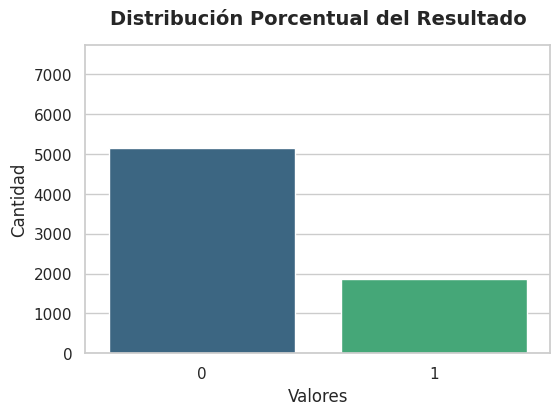

In [70]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='churn', data=concatenado, palette='viridis')
#ax = sns.countplot(x=concatenado['tu_columna'], data=df, palette='Set2')
total_filas = len(concatenado['churn'])

#for container in ax.containers:
    # Calcula el porcentaje para cada barra y lo formatea con 1 decimal y el símbolo %
  #  labels = [f'{(v.get_height() / total_filas) * 100:.1f}%' for v in container]
  #  ax.bar_label(container, labels=labels, label_type='edge', fontsize=12, fontweight='bold')

plt.title('Distribución Porcentual del Resultado', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Valores', fontsize=12)
plt.ylabel('Cantidad', fontsize=12) 

plt.ylim(0, total_filas * 1.1 if 'total_filas' in locals() else ax.get_ylim()[1] * 1.1)
plt.show()



Vemos claramente un desbalance de los datos, es algo que deberemos tomar en cuenta para la creacion del modelo.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b><br><br>
Bien identificado el desbalance de clases. Tenerlo presente es importante, y se ve que después lo tomás en cuenta al usar <code>class_weight='balanced'</code> en los modelos.
</div>

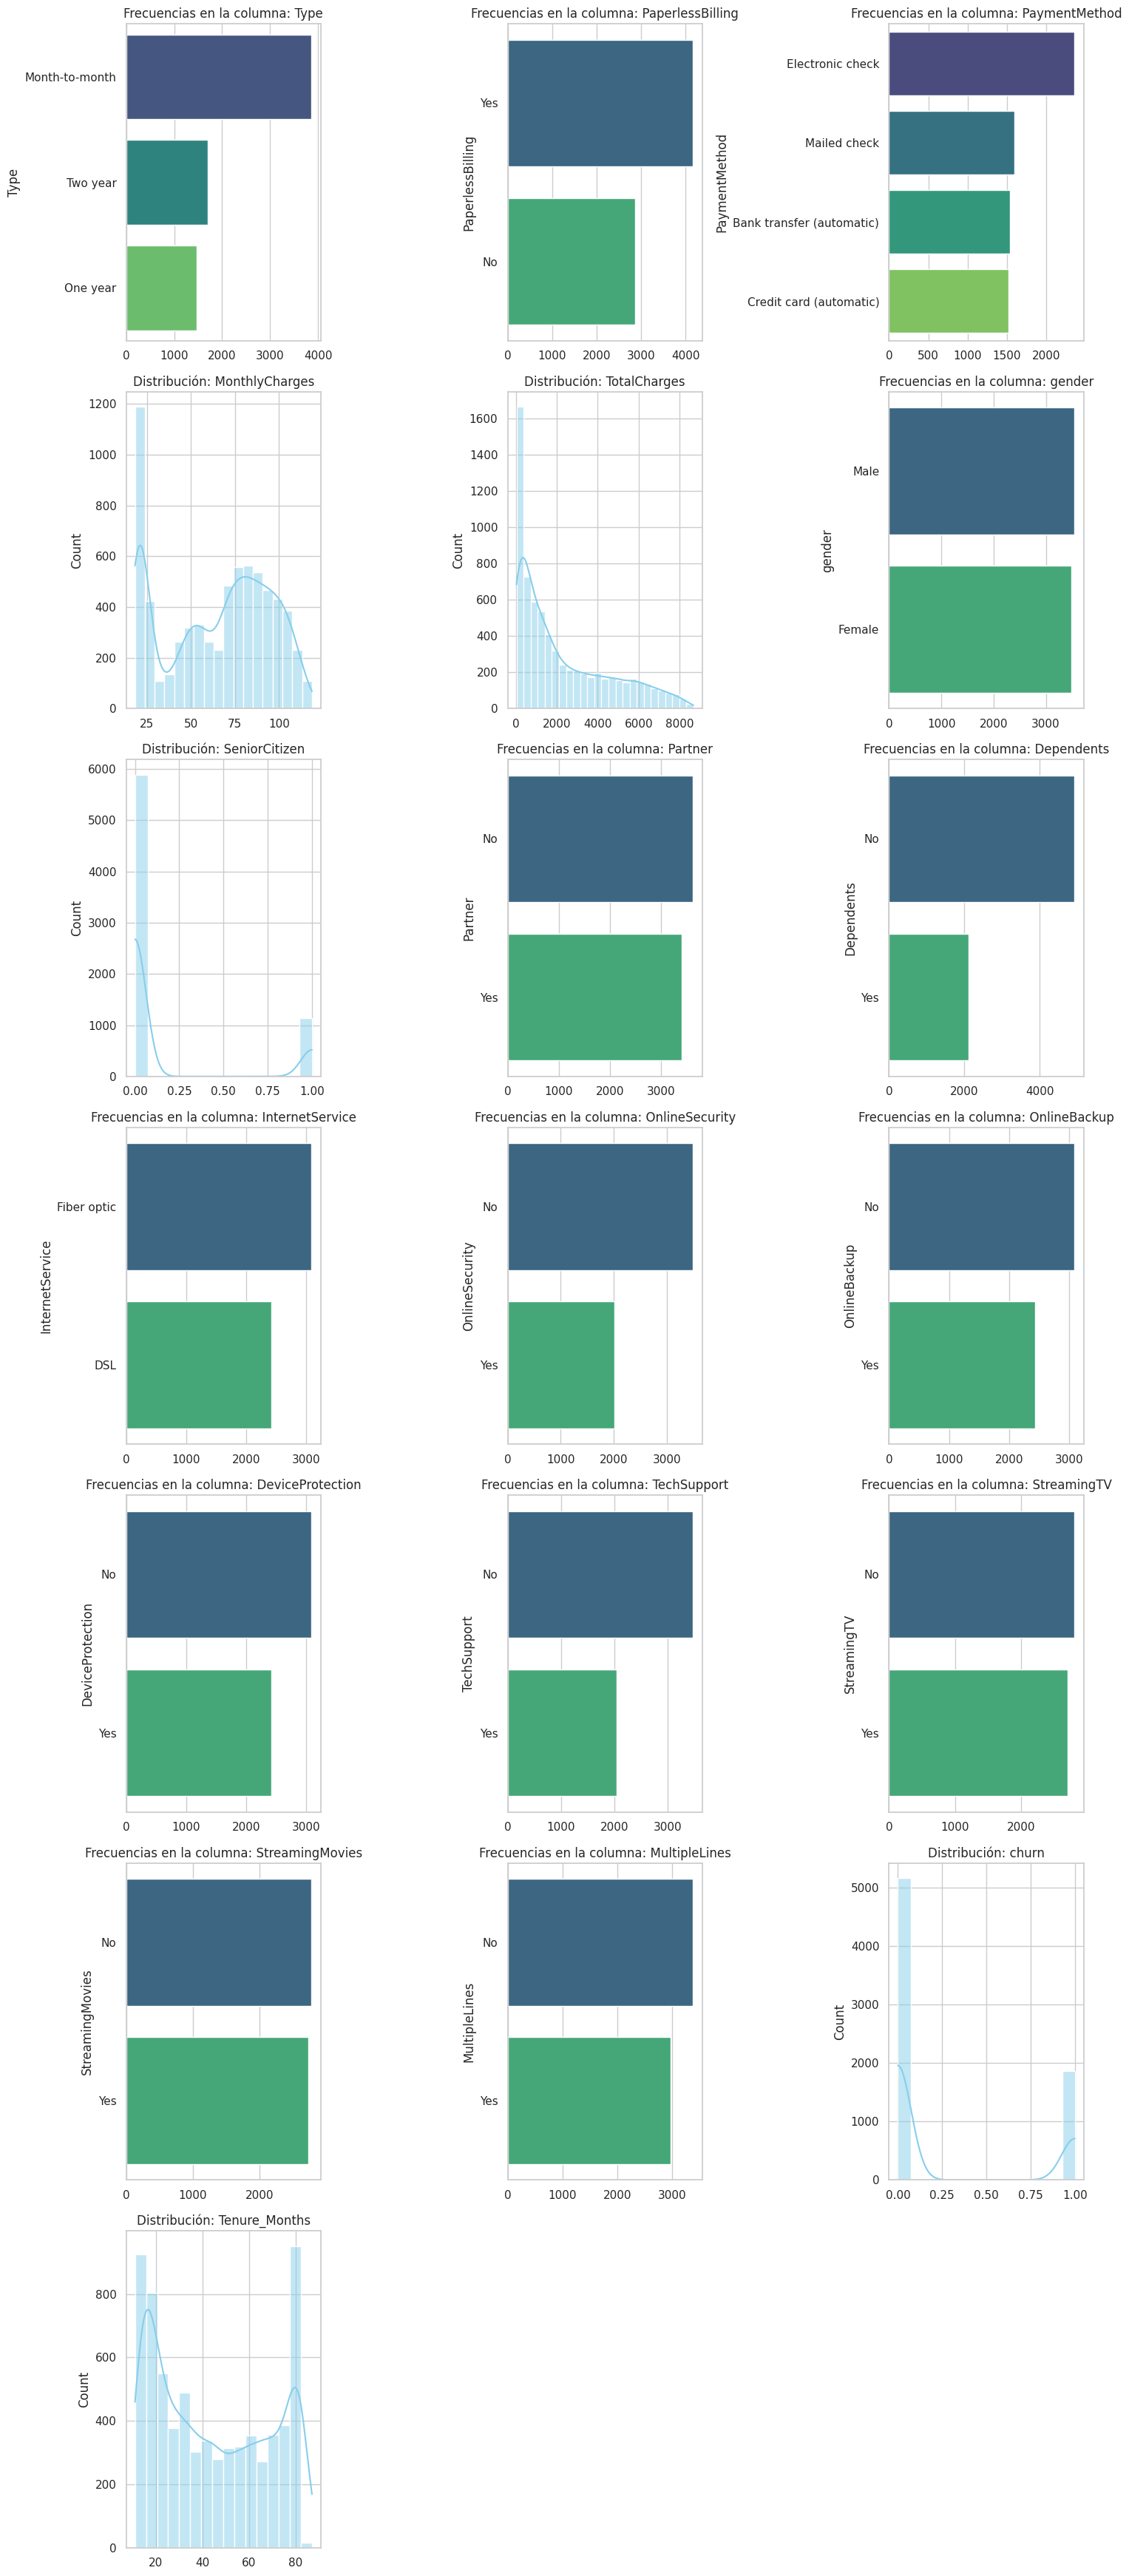

In [71]:

### Usamos esta celda para graficar la distribucion de todas las columnas del data frame concatenado, tanto numericas como categoricas, en un solo grafico

# Configurar dimensiones de la cuadrícula
num_columnas = len(concatenado.columns)
num_filas = math.ceil(num_columnas / 3)

# Crear la fila principal y los ejes
fig, axes = plt.subplots(num_filas, 3, figsize=(15, num_filas * 5))
axes = axes.flatten()  # Aplanar los ejes para un acceso más fácil

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Bucle para recorrer cada columna del DataFrame
for i, columna in enumerate(concatenado.columns):
    ax = axes[i]
    
    # Si la columna es numérica (int o float)
    if concatenado[columna].dtype in ['int64', 'float64']:
        sns.histplot(data=concatenado, x=columna, kde=True, color='skyblue', ax=ax)
        ax.set_title(f'Distribución: {columna}')
        
        
    # Si la columna es de texto o categórica (object o category)
    else:
        # Mostramos las 10 categorías más frecuentes para no saturar el gráfico
        top_categorias = concatenado[columna].value_counts().iloc[:10]
        sns.barplot(x=top_categorias.values, y=top_categorias.index, palette='viridis', ax=ax)
        ax.set_title(f'Frecuencias en la columna: {columna}')
        ax.set_xlabel('Conteo')
        ax.set_ylabel(columna)

    ax.set_xlabel('')

# Ocultar los subgraficos vacios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show() 

## Seleccion de datos

Correlacion de los datos

Crearemos una matriz de correlacion para validar cuales columnas son utiles para entrenar a nuestro modelo

### Encoding de las columnas categoricas

Es de utilidad hacer el encoding de las categorias para que podamos hacer la matriz de correlacion para todas las columnas

Hagamos un analisis de las variables y los posibles resultados para decidir el mejor encoder para cada variable

In [72]:
# Creamos un encoding para las columnas categoricas
columnas_binarias_y_n = ['PaperlessBilling', 'Partner', 'Dependents', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in columnas_binarias_y_n:
    concatenado[col] = concatenado[col].map({'Yes': 1, 'No' :0})

concatenado['gender'] = concatenado['gender'].map({'Female': 1, 'Male': 0})


In [73]:
# Validamos los nulos actuales en el data set
print('='*50)
print('Validacion de nulos')
print('='*50)
print(concatenado.isna().sum())


Validacion de nulos
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges          11
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1515
OnlineSecurity      1515
OnlineBackup        1515
DeviceProtection    1515
TechSupport         1515
StreamingTV         1515
StreamingMovies     1515
MultipleLines        682
churn                  0
Tenure_Months          0
dtype: int64


### Tratamiento de valores nulos

* Los usuarios nuevos no tienen total charges, por lo que vamos a reemplazar los valores nulos de esta columna por 0 
* Los usuarios que solo contrataron el servicio de internet marcan los valores de los otros servicios como nulos, es lo que podemos ver al filtrar el data set con los valores nulos de las columnas, vemos que si ponemos la condicion la suma es la misma de los valores nulos totales. Por esta razon cambiaremos el valor na por el valor 0 para estas columnas
* Los valores nulos de la columna MultipleLines indica los usuarios que no tienen servicio de telefono.

In [74]:
df = concatenado

# Nuevos usuarios
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Usuarios solo internet || primero comprobamos que los daots estan ligados en las columnas.
display(df[(df['InternetService'].isna()) & (df['OnlineSecurity'].isna()) & (df['OnlineBackup'].isna()) & (df['DeviceProtection'].isna()) & (df['TechSupport'].isna()) & (df['StreamingTV'].isna()) & (df['StreamingMovies'].isna())].count())
solo_int = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in solo_int:
    df[col] = df[col].fillna(0)

# MultipleLines, usuarios que contrataron solo telefono.
print('Entradas que deben ser corregidas')
display(df[df['MultipleLines'].isna()==True])
df['MultipleLines'] = df['MultipleLines'].fillna('No')

print('='*50)
print('Validacion de nulos')
print('Informacion despues de las correccciones')
print('='*50)
print(df.isna().sum())

Type                1515
PaperlessBilling    1515
PaymentMethod       1515
MonthlyCharges      1515
TotalCharges        1515
gender              1515
SeniorCitizen       1515
Partner             1515
Dependents          1515
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
MultipleLines       1515
churn               1515
Tenure_Months       1515
dtype: int64

Entradas que deben ser corregidas


,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,churn,Tenure_Months
customerID,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Month-to-month,1,Electronic check,29.85,29.85,1,0,1,0,DSL,0.0,1.0,0.0,0.0,0.0,0.0,NaN,0,12
7795-CFOCW,One year,0,Bank transfer (automatic),42.30,1840.75,0,0,0,0,DSL,1.0,0.0,1.0,1.0,0.0,0.0,NaN,0,56
6713-OKOMC,Month-to-month,0,Mailed check,29.75,301.90,1,0,0,0,DSL,1.0,0.0,0.0,0.0,0.0,0.0,NaN,0,21
8779-QRDMV,Month-to-month,1,Electronic check,39.65,39.65,0,1,0,0,DSL,0.0,0.0,1.0,0.0,0.0,1.0,NaN,1,14
8665-UTDHZ,Month-to-month,0,Electronic check,30.20,30.20,0,0,1,1,DSL,0.0,1.0,0.0,0.0,0.0,0.0,NaN,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4501-VCPFK,Month-to-month,0,Electronic check,35.75,1022.50,0,0,0,0,DSL,0.0,0.0,1.0,1.0,0.0,0.0,NaN,0,37
2274-XUATA,Two year,1,Bank transfer (automatic),63.10,4685.55,0,1,1,0,DSL,1.0,1.0,1.0,1.0,1.0,1.0,NaN,0,82
2235-DWLJU,Month-to-month,1,Electronic check,44.40,263.05,1,1,0,0,DSL,0.0,0.0,0.0,0.0,1.0,1.0,NaN,0,17


Validacion de nulos
Informacion despues de las correccciones
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
churn               0
Tenure_Months       0
dtype: int64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b><br><br>
Muy bien el tratamiento de los nulos estructurales. Distinguís correctamente los tres casos: los clientes nuevos sin <code>TotalCharges</code>, los que solo tienen internet (y por eso quedan nulos los otros servicios) y los que solo tienen teléfono. Y validás con una condición que la cantidad de nulos coincide, que es un buen control.
</div>

In [75]:
print(df['MultipleLines'].value_counts())

No     4059
Yes    2971
Name: MultipleLines, dtype: int64


Vemos que aun tenemos que hacer encoding para los valores de la columna 'MultipleLines'

In [76]:
print(df['InternetService'].value_counts().index)

Index(['Fiber optic', 'DSL', 0], dtype='object')


In [77]:
df['MultipleLines'] = df['MultipleLines'].map({'Yes': 1, 'No' :0})

Nos falta muy poco para terminar de hacer el encoding de todos los datos en nuestro dataset, vemos que para los valores de las columnas Type y PaymentMethod hay mas de dos valores, por ello es conveniente usar One hot encoding para codificar los valores de estas columnas.

Dejemos a un lado por un momento los valores de las columnas restantes para hacer nuestra matriz de correlacion y ver como se relacionan las variables para seleccionar las mejores para nuestro moedelo.

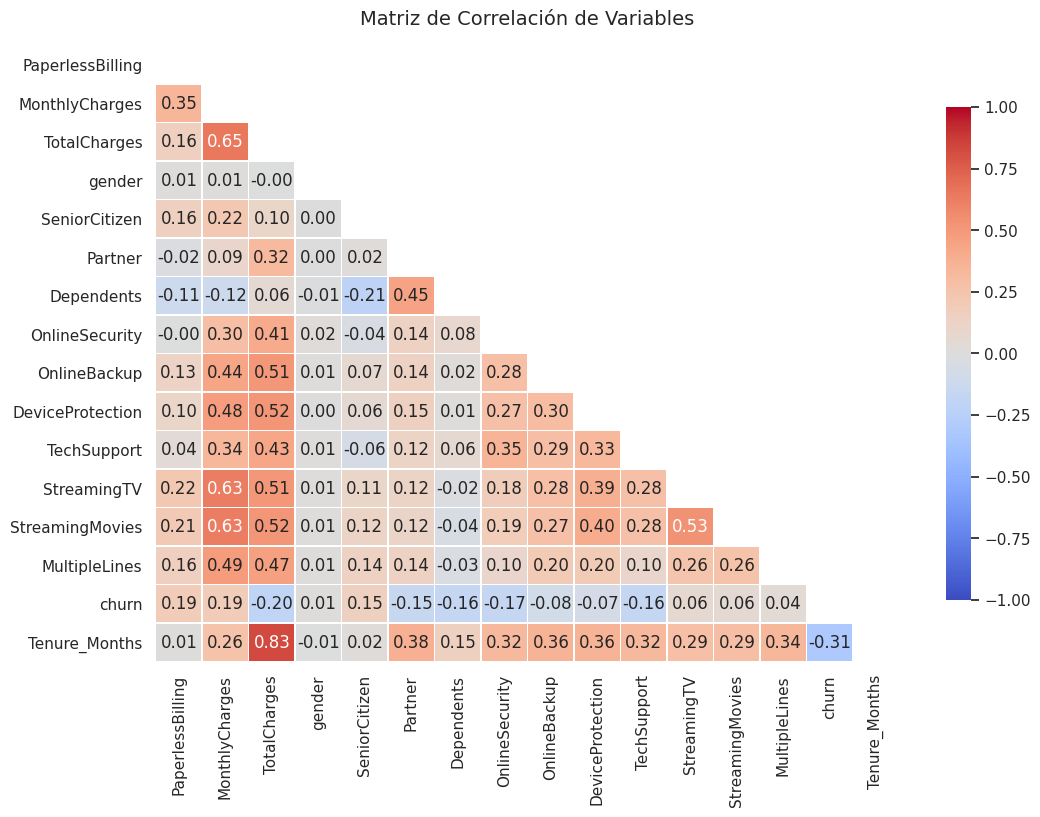

In [78]:
restantes = ['Type', 'PaymentMethod', 'InternetService']
numeric_cols = df.drop(restantes, axis=1)
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12,8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
)

plt.title('Matriz de Correlación de Variables', fontsize=14, pad=15)
plt.show()


In [79]:
# Buscar pares de variables con correlación mayor a 0.80 (excluyendo la diagonal principal)
high_corr = (
    corr_matrix.abs().unstack().sort_values(ascending=False).drop_duplicates()
)
high_corr = high_corr[(high_corr > 0.80) & (high_corr < 1.0)]

print("Pares de variables con alta multicolinealidad (|r| > 0.80):")
print(high_corr)

Pares de variables con alta multicolinealidad (|r| > 0.80):
Tenure_Months  TotalCharges    0.828654
dtype: float64


Vemos que la columna TotalCharges tiene una alta correlacion con la caracteristica MonthlyCharges

Eliminemos esta caracteristica para evitar multicolinealidad.

Continuemos separando los datos.

In [80]:
df = df.drop(columns=['TotalCharges'])

In [81]:
print(df['InternetService'].unique())
df['InternetService'] = df['InternetService'].replace(0, 'No')

['DSL' 'Fiber optic' 0]


In [82]:
# Separamos los datos

X = df.drop('churn', axis=1)
y = df['churn']


X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=42,
    stratify=y_temp
)


Una vez separadas las variables podemos trabajar con el pipeline para terminar de configurar nuestro dataset para entrenar nuestro modelo.

In [83]:
restantes = ['Type', 'PaymentMethod', 'InternetService']


ohe_transformer = OneHotEncoder(drop='first', sparse=False)

preprocessor = ColumnTransformer(transformers=[('cat_ohe', ohe_transformer, restantes)], remainder='passthrough')


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b><br><br>
Dos observaciones acá:<br><br>
<b>1.</b> Al codificar la prueba usás <code>preprocessor.fit_transform(X_test)</code>. Lo correcto es <code>transform</code>, ajustando el codificador solo con el entrenamiento, porque con <code>fit_transform</code> se reajusta sobre la prueba. En el pipeline de la celda siguiente ya lo hacés bien (el <code>fit</code> va sobre <code>X_train</code>), así que esta celda queda como un cálculo suelto que conviene corregir o quitar.<br><br>
<b>2.</b> Más arriba concluís que <code>TotalCharges</code> tiene alta correlación con <code>MonthlyCharges</code> y decidís eliminarla, pero en la separación de datos la columna sigue estando. Si querés evitar la multicolinealidad que detectaste, faltaría hacer el <code>drop</code> efectivo de esa columna.
</div>

## Modelos predictivos.

Vamos a crear varios modelos y medir los mejores resultados


In [84]:
modelos = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),

    'AdaBoost': AdaBoostClassifier(
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),

    'Dummy': DummyClassifier(
        strategy='most_frequent',
        random_state=42
    )
}

resultados = []
pipelines = {}

for nombre, algoritmo in modelos.items():

    pipeline_eval = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', algoritmo)
        ]
    )

    # Entrenamiento SOLO con Train
    pipeline_eval.fit(X_train, y_train)

    # Guardamos el pipeline para utilizarlo después
    pipelines[nombre] = pipeline_eval

    # Predicciones SOLO sobre Validation
    y_pred = pipeline_eval.predict(X_valid)
    y_proba = pipeline_eval.predict_proba(X_valid)[:, 1]

    # Métricas de Validation
    acc = accuracy_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_proba)

    resultados.append({
        'Modelo': nombre,
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'ROC-AUC': round(roc_auc, 4)
    })

df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by='F1-Score',
    ascending=False
)

display(df_resultados)

/.venv/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,Modelo,Accuracy,F1-Score,Precision,Recall,ROC-AUC
0,Logistic Regression,0.7600,0.6494,0.5308,0.8361,0.8441
3,AdaBoost,0.8124,0.6184,0.6732,0.5719,0.8721
4,XGBoost,0.8000,0.5961,0.6434,0.5552,0.8444
2,Random Forest,0.7991,0.5670,0.6637,0.4950,0.8436
1,Decision Tree,0.7378,0.5025,0.5068,0.4983,0.6611
5,Dummy,0.7342,0.0000,0.0000,0.0000,0.5000


Veamos que tenemos dos candidatos, Ligistic regresion por tener el mejor F1-Score de 0.6494 y Recall 0.8361 y AdaBoost por tener los mejores indicadores de Accuracy 0.8124, Precision 0.6732 y ROC-AUC 0.8721, para la seleccion del mejor modelo, pero antes debemos hacer un analisis mas profundo.

Veamos los mejores umbrales para la clasificacion, para que ajustemos nuestro modelo y verifiquemos si hay alguna diferencia importante en los nuevos resultados.

In [85]:
resultados_threshold_modelos = []

for nombre, modelo in pipelines.items():

    if nombre == 'Dummy':
        continue

    y_proba = modelo.predict_proba(X_valid)[:, 1]

    #Queremos identificar varios thresholds para ver cual es el mejor por ello usamos un rango de .10 a 0.91 teniendo como resultado 81 ventanas posibles.
    for threshold in np.arange(0.10, 0.91, 0.01):

        y_pred = (y_proba >= threshold).astype(int)

        f1 = f1_score(y_valid, y_pred)
        precision = precision_score(y_valid, y_pred)
        recall = recall_score(y_valid, y_pred)

        resultados_threshold_modelos.append({
            'Modelo': nombre,
            'Threshold': round(threshold, 2),
            'F1-Score': f1,
            'Precision': precision,
            'Recall': recall
        })

# Convertimos los resultados a un dataframe para poder agrupar y presentar los valores deseados
df_threshold_modelos = pd.DataFrame(
    resultados_threshold_modelos
)

mejores_thresholds = (
    df_threshold_modelos
    .sort_values('F1-Score', ascending=False)
    .groupby('Modelo')
    .head(1)
    .sort_values('F1-Score', ascending=False)
)

display(mejores_thresholds)

/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 

,Modelo,Threshold,F1-Score,Precision,Recall
49,Logistic Regression,0.59,0.657183,0.571782,0.772575
185,Random Forest,0.33,0.651026,0.579634,0.742475
353,XGBoost,0.39,0.638298,0.584958,0.702341
283,AdaBoost,0.50,0.618445,0.673228,0.571906
98,Decision Tree,0.27,0.502530,0.506803,0.498328


Calificando los mejores thresholds para los modelos, vemos que Logistic Regression sigue ganando para ser el moejor modelo.

Veamos entonces para este modelo los mejores lumbrales y seleccionemos una cota ahora con el conjunto de validacion.

In [86]:
modelo = pipelines['Logistic Regression']

# Probabilidades sobre VALIDATION
y_proba = modelo.predict_proba(X_valid)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)

resultados_threshold = []

for threshold in thresholds:

    y_pred = (y_proba >= threshold).astype(int)

    f1 = f1_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)

    resultados_threshold.append({
        'Threshold': threshold,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    })

resultados_threshold = pd.DataFrame(resultados_threshold)

display(
    resultados_threshold
    .sort_values('F1-Score', ascending=False)
    .head(10)
)

,Threshold,F1-Score,Precision,Recall
49,0.59,0.657183,0.571782,0.772575
48,0.58,0.655367,0.567237,0.775920
51,0.61,0.653061,0.578811,0.749164
50,0.60,0.650360,0.570707,0.755853
40,0.50,0.649351,0.530786,0.836120
41,0.51,0.649215,0.533333,0.829431
42,0.52,0.646438,0.533769,0.819398
46,0.56,0.646409,0.550588,0.782609
47,0.57,0.646240,0.553699,0.775920
45,0.55,0.645777,0.544828,0.792642


El mejor threshold para el modelo es 0.59 y Logistic regresion es el modelo ganador.

Hagamos entonces la prueba con este dato en el conjunto de validacion y veamos los resultados del modelo.

## Conclusiones

Los siguientes son los resultados del mejor modelo

In [87]:
# Modelo ganador
modelo_final = pipelines['Logistic Regression']

# Threshold seleccionado usando VALIDATION
threshold_final = 0.59

# Probabilidades sobre TEST
y_proba_test = modelo_final.predict_proba(X_test)[:, 1]

# Clasificación usando el threshold elegido
y_pred_test = (
    y_proba_test >= threshold_final
).astype(int)

# Métricas finales
accuracy_final = accuracy_score(y_test, y_pred_test)
f1_final = f1_score(y_test, y_pred_test)
precision_final = precision_score(y_test, y_pred_test)
recall_final = recall_score(y_test, y_pred_test)
roc_auc_final = roc_auc_score(y_test, y_proba_test)

print("RESULTADOS FINALES EN TEST")
print("-"*30)
print(f"Accuracy:  {accuracy_final:.4f}")
print(f"F1-Score:  {f1_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall:    {recall_final:.4f}")
print(f"ROC-AUC:   {roc_auc_final:.4f}")

RESULTADOS FINALES EN TEST
------------------------------
Accuracy:  0.7795
F1-Score:  0.6485
Precision: 0.5619
Recall:    0.7668
ROC-AUC:   0.8494


La matriz de confusion es importante para ver como funciona nuestro modelo

In [88]:
cm = confusion_matrix(y_test, y_pred_test)

print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[810 223]
 [ 87 286]]


Veamos que los clientes que no detecta el modelo son pocos, 87 y los que el modelo detecta correctamente son 286

In [ ]:
print(classification_report(
    y_test,
    y_pred_test,
    target_names=['No Churn', 'Churn']
))
print('-'*30)
print()

In [ ]:
resultado_clientes = X_test.copy()

resultado_clientes['Probabilidad_Churn'] = y_proba_test

resultado_clientes['Prediccion_Churn'] = y_pred_test

resultado_clientes = resultado_clientes.sort_values(
    'Probabilidad_Churn',
    ascending=False
)

display(resultado_clientes.head(20))

Catalogamos a los clientes con un nivel de riesgo de dejar el servicio.

In [ ]:
resultado_clientes['Nivel_Riesgo'] = pd.cut(
    resultado_clientes['Probabilidad_Churn'],
    bins=[0, 0.30, 0.60, 1],
    labels=['Bajo', 'Medio', 'Alto']
)

display(resultado_clientes)

Hagamos un panorama de los datos en estos clientes.

El porcentaje de clientes que dejan el servicio.


In [ ]:
porcentaje_churn = df['churn'].mean() * 100

print(f"Porcentaje de clientes que abandonaron: {porcentaje_churn:.2f}%")

In [ ]:
print('-'*30)
print('Porcentaje de clientes que abandonaron según tipo de contrato:')
churn_contrato = pd.crosstab(
    df['Contract'],
    df['churn'],
    normalize='index'
) * 100

display(churn_contrato)

In [ ]:
print('-'*30)
print('Porcentaje de clientes que abandonaron según antigüedad:')
df['tenure_group'] = pd.cut(
    df['Tenure_Months'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6', '7-12', '13-24', '25-48', '49-72']
)

churn_tenure = pd.crosstab(
    df['tenure_group'],
    df['churn'],
    normalize='index'
) * 100

display(churn_tenure)

In [ ]:
print('-'*30)
print('Porcentaje de clientes que abandonaron según cargos mensuales:')
df['charges_group'] = pd.qcut(
    df['MonthlyCharges'],
    q=4
)

churn_charges = pd.crosstab(
    df['charges_group'],
    df['churn'],
    normalize='index'
) * 100

display(churn_charges)

Sigue la lista de clinetes con perfil de alto riesgo de abandono.

Estos clientes presentan una alta probabilidad estimada de abandono según el modelo y pueden ser priorizados para acciones de retención.


In [ ]:
clientes_riesgo = resultado_clientes[
    resultado_clientes['Prediccion_Churn'] == 1
].copy()

clientes_riesgo = clientes_riesgo.sort_values(
    'Probabilidad_Churn',
    ascending=False
)

print(f"Clientes identificados como riesgo de churn: {len(clientes_riesgo)}")

display(clientes_riesgo.head(20))

Conclusiones del modelo

Después de comparar diferentes modelos de clasificación, se seleccionó la Regresión Logística debido a que obtuvo el mejor desempeño en F1-Score durante la validación. Además, se estableció un umbral de clasificación de 0.59, seleccionado exclusivamente utilizando el conjunto de validación.

Al evaluar el modelo final sobre el conjunto de prueba, se obtuvo un Accuracy de 0.7795, F1-Score de 0.6485, Precision de 0.5619, Recall de 0.7668 y ROC-AUC de 0.8494.

El resultado más relevante para el objetivo del proyecto es el Recall de 0.7668, ya que el modelo logró identificar correctamente 286 de los 373 clientes que realmente abandonaron el servicio. Esto significa que fue capaz de detectar aproximadamente el 77% de los casos de churn.

La matriz de confusión mostró 810 clientes correctamente clasificados como No Churn y 286 clientes correctamente identificados como Churn. Por otro lado, 87 clientes que abandonaron el servicio no fueron detectados por el modelo y 223 clientes fueron clasificados como posibles casos de churn aunque finalmente permanecieron.

Estos resultados indican que el modelo puede utilizarse como una herramienta de apoyo para identificar clientes con mayor riesgo de abandono. La empresa puede utilizar las probabilidades estimadas por el modelo para priorizar acciones de retención, como ofrecer incentivos, promociones o alternativas de servicio a los clientes con mayor riesgo.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b><br><br>
Los resultados que se muestran (por ejemplo XGBoost con ROC-AUC 0.9999 y F1 0.9947) no son realistas para un problema de cancelación, y son la consecuencia directa de los dos puntos anteriores: la fuga en <code>Tenure_Months</code> y el objetivo invertido. Una vez corregidos, esperá métricas bastante más bajas, que van a reflejar el rendimiento real del modelo.<br><br>
Un punto adicional de método: estás eligiendo el mejor modelo directamente sobre el conjunto de prueba. Para no usar la prueba en la selección, conviene separar también un conjunto de validación (o usar validación cruzada) para comparar los modelos, y dejar la prueba solo para la evaluación final del modelo elegido. Sumá también la línea base con el <code>DummyClassifier</code> que ya importaste, como prueba de cordura.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (segunda iteración)</b><br><br>
Corregido. Ahora las métricas son realistas (ROC-AUC 0.85 y Recall 0.77 en la prueba) y elegís el modelo y el umbral usando el conjunto de validación, reservando la prueba para la evaluación final. El informe de cierre, con el modelo elegido, sus métricas y la recomendación de retención, quedó muy bien y responde al objetivo del proyecto.<br><br>
Dos detalles menores para terminar de pulir: incluís el <code>DummyClassifier</code> entre los modelos pero lo salteás en la comparación, así que convendría mostrar su resultado como línea base de cordura. Además, al final del notebook quedó una celda con el texto de la plantilla (las preguntas aclaratorias y el plan de trabajo) que ya podés eliminar, porque el informe real está más arriba.
</div>

Crear lista de preguntas aclaratorias

- Que debe contener exactamente el proyecto?
- Ademas de los clientes que estan proximos a dejar el servicio, que resultados se esperan del proyecto?
- Como debo continuar, tengo que agendar las sesiones uno a uno?

Plan aproximado con 3 a 5 pasos clave bien definidos y explicados
Es ne

- Analisar los datos
  Verificar que los datos esten balanceados, verificar outliers, identificar las caractericas 
- Que datos usar
  separar los datos en conjuntos de entrenamiento y validacion
- Crear el modelo
  Probar con varios metodos y verificar cual metodo genera mejores metricas y validar que el el mejor de los modelos funcione en las prediciones reales.
- Hacer pruebas con el modelo seleccionado.

Objetivo > (Pronosticar tasa de canlcelamiento) Crear una alerta de usuarios proximos a dejar el servicio para ofrecerles cupones de descuento 

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b><br><br>
El notebook termina acá con texto que parece de la plantilla (la lista de preguntas aclaratorias y el plan de trabajo), pero falta el cierre del proyecto: un <b>informe final</b> con las conclusiones, el modelo elegido y su métrica en la prueba, y una breve recomendación de negocio acorde al objetivo de alertar a los clientes próximos a irse. Ese reporte es una parte esperada de la entrega. Con eso, más las correcciones de la fuga y del objetivo, el proyecto queda completo.
</div>